# CFRM 521/421 Machine Learning for Finance
## Course Project Template

**Project Title:** Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: ___, Algorithm: Neural Network with MLP)  
- Summer Zhu (email: ___, Algorithm: Random Forest)   

**Date:**

<span style="color:red">
**Please remove the bullet points in each section as you proceed and feel free to adjust the structure and contents as needed.
</span>

# 1. Introduction

## 1.1 Problem Statement
- What is the goal of your project?
- Why is this problem important in finance?
- What financial decision, prediction, or classification task are you studying?

## 1.2 Related Literature
- Briefly summarize relevant papers or prior work.
- Explain how your project relates to existing studies.
- Cite all sources properly.

## 1.3 Contribution
- What does your project add beyond existing work?
- Is your contribution empirical comparison, replication with extensions, new data, or a new application?


# 2. Data Description

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


In [3]:
!pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.6-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (18 kB)
  Using cached websockets-16.0-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (6.8 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (11.1 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.6-py3-none-any.whl (146 kB)
Using cached websockets-16.0-cp313-cp313-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl (184 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]4/5 [yfinance]]]


In [2]:
import yfinance as yf

# Load data
tickers = [
    'MSFT',
    'SPY',
    'QQQ',
    'XLK',
    '^VIX',
    '^VXN',
    '^TNX',
    'SOXX',
    'TLT'
]

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)

data.head()


[*********************100%***********************]  8 of 9 completed


Price           Close                                                \
Ticker           MSFT         QQQ       SOXX         SPY        TLT   
Date                                                                  
2016-01-04  47.770721  101.717285  26.696756  169.908157  90.984604   
2016-01-05  47.988651  101.540802  26.444210  170.195541  90.617462   
2016-01-06  47.116920  100.565453  25.530272  168.048630  91.838608   
2016-01-07  45.478092   97.416382  24.814743  164.016922  92.003456   
2016-01-08  45.617550   96.617516  24.456991  162.216537  92.415512   

Price                                                    High  ...       Open  \
Ticker            XLK   ^TNX       ^VIX       ^VXN       MSFT  ...       ^VXN   
Date                                                           ...              
2016-01-04  18.860451  2.245  20.700001  22.420000  47.770721  ...  19.629999   
2016-01-05  18.811367  2.248  19.340000  21.559999  48.285039  ...  22.440001   
2016-01-06  18.579353  2.177  20.590000  22.480000  47.422027  ...  21.559999   
2016-01-07  18.030537  2.153  24.990000  26.770000  46.628777  ...  22.500000   
2016-01-08  17.887754  2.130  27.010000  28.330000  46.445689  ...  26.879999   

Price         Volume                                                         \
Ticker          MSFT       QQQ     SOXX        SPY       TLT       XLK ^TNX   
Date                                                                          
2016-01-04  53778000  50807600  1023000  222353500  10591900  43277200  0.0   
2016-01-05  34079700  38795200  1329000  110845800   6242600  32134400  0.0   
2016-01-06  39518900  41891100  1541100  152112600   8916900  27716800  0.0   
2016-01-07  56564900  61386300  2026800  213436100  10202200  33681400  0.0   
2016-01-08  48754000  69344000  1465200  209817200   9577200  38466200  0.0   

Price                 
Ticker     ^VIX ^VXN  
Date                  
2016-01-04    0    0  
2016-01-05    0    0  
2016-01-06    0    0  
2016-01-07    0    0  
2016-01-08    0    0  

[5 rows x 45 columns]

In [3]:
# Flatten MultiIndex columns
data.columns = [f"{ticker}_{price}" for price, ticker in data.columns]

# Rename ^VIX to VIX for easier use
data = data.rename(columns=lambda x: 
    x.replace('^VIX', 'VIX')
     .replace('^VXN', 'VXN')
     .replace('^TNX', 'TNX')
)

# Check column names
data.columns

# Create a working dataframe
df = data.copy()

# =========================
# 1. Daily returns
# =========================

df['MSFT_return_1d'] = df['MSFT_Close'].pct_change()
df['SPY_return_1d'] = df['SPY_Close'].pct_change()
df['QQQ_return_1d'] = df['QQQ_Close'].pct_change()
df['XLK_return_1d'] = df['XLK_Close'].pct_change()


# =========================
# 2. MSFT lag returns
# =========================

df['MSFT_return_lag1'] = df['MSFT_return_1d'].shift(1)
df['MSFT_return_lag3'] = df['MSFT_return_1d'].shift(3)
df['MSFT_return_lag5'] = df['MSFT_return_1d'].shift(5)
df['MSFT_return_lag10'] = df['MSFT_return_1d'].shift(10)
df['MSFT_return_lag15'] = df['MSFT_return_1d'].shift(15)
df['MSFT_return_lag21'] = df['MSFT_return_1d'].shift(21)


# =========================
# 3. MSFT rolling volatility
# =========================

df['MSFT_rolling_vol_5'] = df['MSFT_return_1d'].rolling(window=5).std()
df['MSFT_rolling_vol_21'] = df['MSFT_return_1d'].rolling(window=21).std()


# =========================
# 4. MSFT log volume
# =========================

df['MSFT_log_volume'] = np.log(df['MSFT_Volume'])


# =========================
# 5. SPY market-wide features
# =========================

df['SPY_return_lag1'] = df['SPY_return_1d'].shift(1)
df['SPY_rolling_vol_5'] = df['SPY_return_1d'].rolling(window=5).std()
df['SPY_rolling_vol_21'] = df['SPY_return_1d'].rolling(window=21).std()


# =========================
# 6. QQQ technology market features
# =========================

df['QQQ_rolling_vol_21'] = df['QQQ_return_1d'].rolling(window=21).std()


# =========================
# 7. VIX features
# =========================

df['VIX_level'] = df['VIX_Close']
df['VIX_change'] = df['VIX_Close'].pct_change()
df['VIX_lag1'] = df['VIX_Close'].shift(1)


# =========================
# 8. XLK sector ETF features
# =========================

df['XLK_rolling_vol_5'] = df['XLK_return_1d'].rolling(window=5).std()
df['XLK_rolling_vol_21'] = df['XLK_return_1d'].rolling(window=21).std()


# =========================
# 9. Relative performance features
# =========================

df['MSFT_minus_XLK_return'] = df['MSFT_return_1d'] - df['XLK_return_1d']
df['MSFT_minus_SPY_return'] = df['MSFT_return_1d'] - df['SPY_return_1d']



# =========================
# 10. Additional features added
# =========================

# Longer MSFT rolling volatility
df['MSFT_rolling_vol_63'] = df['MSFT_return_1d'].rolling(window=63).std()
df['MSFT_rolling_vol_126'] = df['MSFT_return_1d'].rolling(window=126).std()

# Smoothed VIX features
df['VIX_rolling_mean_21'] = df['VIX_level'].rolling(window=21).mean()
df['VIX_rolling_mean_63'] = df['VIX_level'].rolling(window=63).mean()

# Nasdaq volatility index features
df['VXN_level'] = df['VXN_Close']
df['VXN_change'] = df['VXN_Close'].pct_change()
df['VXN_lag1'] = df['VXN_Close'].shift(1)

# 10-year Treasury yield features
df['TNX_level'] = df['TNX_Close']
df['TNX_change'] = df['TNX_Close'].pct_change()
df['TNX_lag1'] = df['TNX_Close'].shift(1)

# Semiconductor ETF features
df['SOXX_return_1d'] = df['SOXX_Close'].pct_change()
df['SOXX_rolling_vol_21'] = df['SOXX_return_1d'].rolling(window=21).std()

# Long-term Treasury ETF features
df['TLT_return_1d'] = df['TLT_Close'].pct_change()
df['TLT_rolling_vol_21'] = df['TLT_return_1d'].rolling(window=21).std()


# Check result
df.head()

# =========================
# 11. Target variables
# =========================

# Daily prediction target
df['target_volatility_1d'] = df['MSFT_return_1d'].shift(-1).abs()

# Weekly prediction target
df['target_volatility_5d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=5)
    .std()
    .shift(-4)
)

# Monthly prediction target
df['target_volatility_21d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=21)
    .std()
    .shift(-20)
)

/tmp/ipykernel_388/4200851859.py:115: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['TNX_change'] = df['TNX_Close'].pct_change()


In [11]:
# =========================
# 12. Final model dataset
# =========================

core_feature_cols = [
    'MSFT_return_1d',
    'MSFT_return_lag1',
    'MSFT_return_lag3',
    'MSFT_return_lag5',
    'MSFT_return_lag10',
    'MSFT_return_lag15',
    'MSFT_return_lag21',
    'MSFT_rolling_vol_5',
    'MSFT_rolling_vol_21',
    'MSFT_log_volume',
    
    'SPY_return_1d',
    'SPY_return_lag1',
    'SPY_rolling_vol_5',
    'SPY_rolling_vol_21',
    
    'QQQ_return_1d',
    'QQQ_rolling_vol_21',
    
    'VIX_level',
    'VIX_change',
    'VIX_lag1',
    
    'XLK_return_1d',
    'XLK_rolling_vol_5',
    'XLK_rolling_vol_21',
    
    'MSFT_minus_XLK_return',
    'MSFT_minus_SPY_return'
]

additional_feature_cols = [
    'MSFT_rolling_vol_63',
    'MSFT_rolling_vol_126',
    
    'VIX_rolling_mean_21',
    'VIX_rolling_mean_63',
    
    'VXN_level',
    'VXN_change',
    'VXN_lag1',
    
    'TNX_level',
    'TNX_change',
    'TNX_lag1',
    
    'SOXX_return_1d',
    'SOXX_rolling_vol_21',
    
    'TLT_return_1d',
    'TLT_rolling_vol_21'
]

feature_cols = core_feature_cols + additional_feature_cols

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

# Dataset before dropna
model_data_before_dropna = df[feature_cols + target_cols].copy()

# Total number of NaN values
total_na = model_data_before_dropna.isna().sum().sum()
print("Shape before dropna:", model_data_before_dropna.shape)
print("Total NaN values before dropna:", total_na)

# NaN values by column
na_by_column = model_data_before_dropna.isna().sum()
na_by_column[na_by_column > 0]
print("NaN values by column:", na_by_column[na_by_column > 0])

# Number of rows with at least one NaN
rows_with_na = model_data_before_dropna.isna().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_na)

# Keep only features and targets, then drop missing values
model_data = df[feature_cols + target_cols].dropna()

print("Final model_data shape:", model_data.shape)

model_data.head()

Shape before dropna: (2514, 41)
Total NaN values before dropna: 518
NaN values by column: MSFT_return_1d             1
MSFT_return_lag1           2
MSFT_return_lag3           4
MSFT_return_lag5           6
MSFT_return_lag10         11
MSFT_return_lag15         16
MSFT_return_lag21         22
MSFT_rolling_vol_5         5
MSFT_rolling_vol_21       21
SPY_return_1d              1
SPY_return_lag1            2
SPY_rolling_vol_5          5
SPY_rolling_vol_21        21
QQQ_return_1d              1
QQQ_rolling_vol_21        21
VIX_change                 1
VIX_lag1                   1
XLK_return_1d              1
XLK_rolling_vol_5          5
XLK_rolling_vol_21        21
MSFT_minus_XLK_return      1
MSFT_minus_SPY_return      1
MSFT_rolling_vol_63       63
MSFT_rolling_vol_126     126
VIX_rolling_mean_21       20
VIX_rolling_mean_63       62
VXN_change                 1
VXN_lag1                   1
TNX_level                  1
TNX_change                 1
TNX_lag1                   2
SOXX_return

,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,TNX_level,TNX_change,TNX_lag1,SOXX_return_1d,SOXX_rolling_vol_21,TLT_return_1d,TLT_rolling_vol_21,target_volatility_1d,target_volatility_5d,target_volatility_21d
Date,,,,,,,,,,,,,,,,,,,,,
2016-07-05,0.000195,-0.000195,0.022249,-0.028095,-0.001197,-0.026030,-0.013148,0.010815,0.016408,17.026612,...,1.367,-0.061126,1.456,-0.018305,0.019387,0.012521,0.010161,0.004104,0.007028,0.013262
2016-07-06,0.004104,0.000195,0.012465,0.020855,0.022368,-0.006182,0.006565,0.009565,0.016365,17.153679,...,1.385,0.013168,1.367,0.001316,0.019400,0.001615,0.009872,0.000000,0.006854,0.013267
2016-07-07,0.000000,0.004104,-0.000195,0.022249,-0.003907,-0.002809,-0.000575,0.005417,0.016365,16.790285,...,1.387,0.001444,1.385,0.012159,0.019486,-0.000070,0.009903,0.017905,0.005754,0.013243
2016-07-08,0.017905,0.000000,0.000195,0.012465,0.018043,0.014087,-0.001152,0.007756,0.016850,17.161583,...,1.366,-0.015141,1.387,0.027814,0.020526,0.007366,0.009931,0.005545,0.004467,0.012974
2016-07-11,0.005545,0.017905,0.004104,-0.000195,-0.040069,-0.005160,-0.008071,0.007318,0.016771,16.918715,...,1.434,0.049780,1.366,0.011267,0.020681,-0.008775,0.010270,0.011789,0.004469,0.012986


In [12]:
# =========================
# 14. Time-series train / validation / test split
# =========================

# Make sure data is sorted by date
model_data = model_data.sort_index()

# Split indices
n = len(model_data)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

# Split data
train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)

print("Train period:", train_data.index.min(), "to", train_data.index.max())
print("Validation period:", valid_data.index.min(), "to", valid_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())

# =========================
# 15. Define X variables
# =========================

X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# =========================
# 16. Define y variables for each prediction horizon
# =========================

# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2365
Train shape: (1655, 41)
Validation shape: (355, 41)
Test shape: (355, 41)
Train period: 2016-07-05 00:00:00 to 2023-02-01 00:00:00
Validation period: 2023-02-02 00:00:00 to 2024-07-02 00:00:00
Test period: 2024-07-03 00:00:00 to 2025-12-01 00:00:00


In [13]:
# =========================
# 17. Standardize X variables
# =========================

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform train, validation, and test using the same scaler
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_valid_scaled shape:", X_valid_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1655, 38)
X_valid_scaled shape: (355, 38)
X_test_scaled shape: (355, 38)


# 3. Exploratory Data Analysis

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [7]:
# Basic summary statistics
# df.describe()

# =========================
# 3.1 Basic summary statistics
# =========================

print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2365, 41)
Start date: 2016-07-05 00:00:00
End date: 2025-12-01 00:00:00


,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,TNX_level,TNX_change,TNX_lag1,SOXX_return_1d,SOXX_rolling_vol_21,TLT_return_1d,TLT_rolling_vol_21,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,...,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000
mean,0.001150,0.001158,0.001153,0.001135,0.001175,0.001124,0.001165,0.014261,0.015178,17.041344,...,2.725900,0.000884,2.724828,0.001200,0.018978,-0.000036,0.008799,0.011601,0.014278,0.015155
std,0.016888,0.016882,0.016891,0.016896,0.016918,0.016895,0.016913,0.010047,0.007820,0.370675,...,1.186787,0.030922,1.186718,0.020846,0.009008,0.009538,0.003836,0.012319,0.010044,0.007820
min,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,0.000687,0.003444,15.784649,...,0.499000,-0.293201,0.499000,-0.152278,0.005004,-0.066683,0.004179,0.000000,0.000687,0.003444
25%,-0.006429,-0.006426,-0.006429,-0.006429,-0.006367,-0.006367,-0.006327,0.007863,0.010159,16.786884,...,1.716000,-0.012129,1.716000,-0.008991,0.013013,-0.005724,0.006361,0.003456,0.007885,0.010159
50%,0.001087,0.001087,0.001101,0.001070,0.001109,0.001049,0.001070,0.011897,0.013573,16.998933,...,2.659000,0.000000,2.657000,0.001562,0.017282,0.000253,0.007811,0.008054,0.011928,0.013528
75%,0.009736,0.009736,0.009736,0.009736,0.009799,0.009736,0.009790,0.017963,0.018380,17.254084,...,3.886000,0.012633,3.883000,0.012353,0.022723,0.005516,0.010533,0.015709,0.017965,0.018355
max,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.121416,0.071032,18.527219,...,4.988000,0.498998,4.988000,0.185716,0.075430,0.075195,0.038652,0.147390,0.121416,0.071032


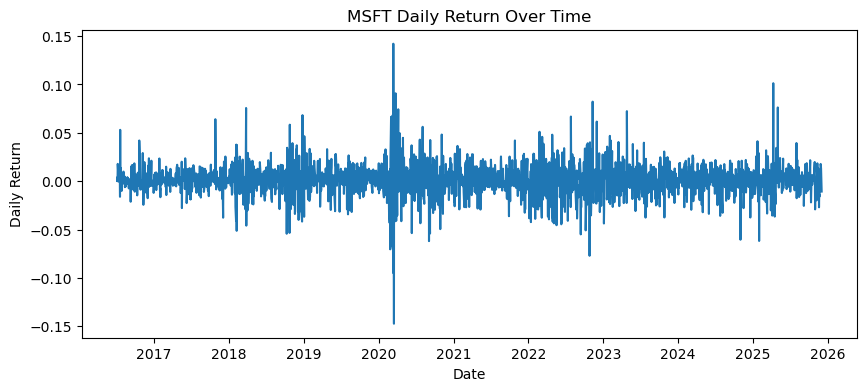

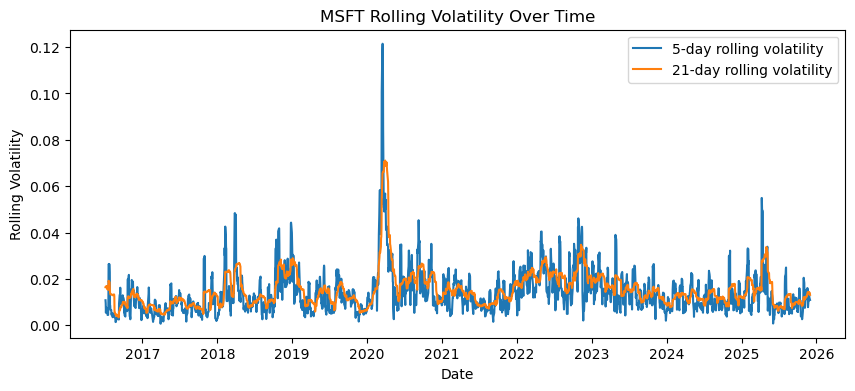

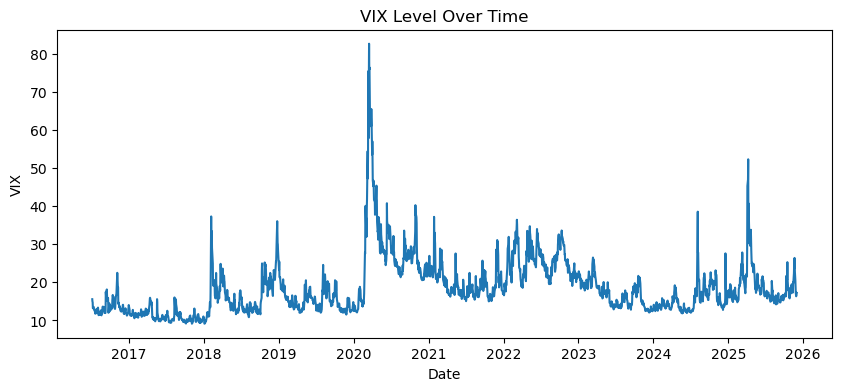

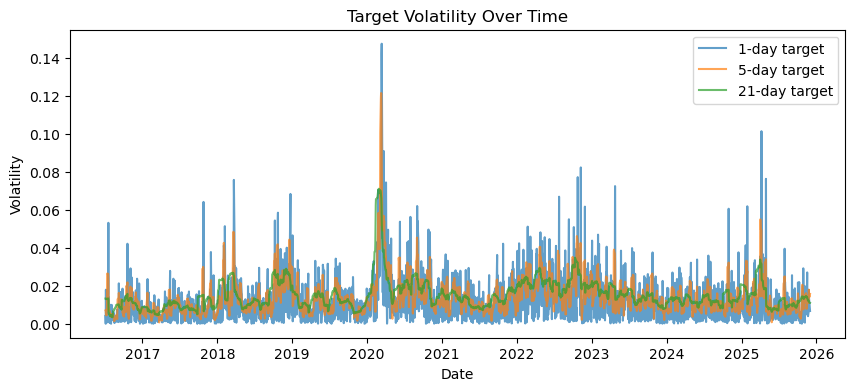

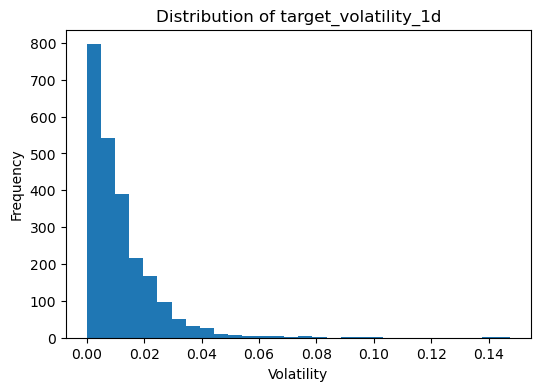

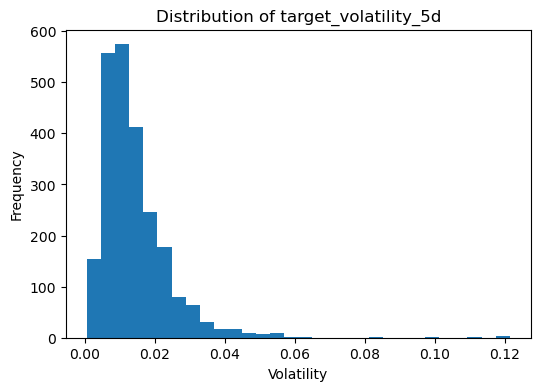

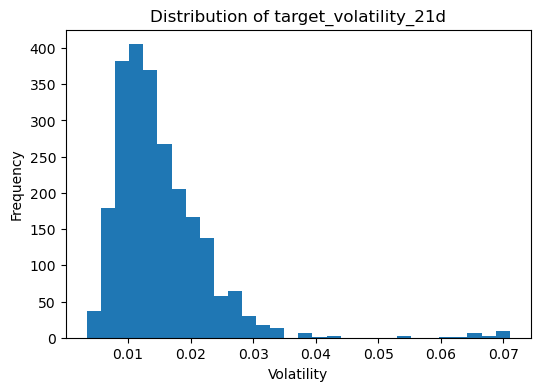

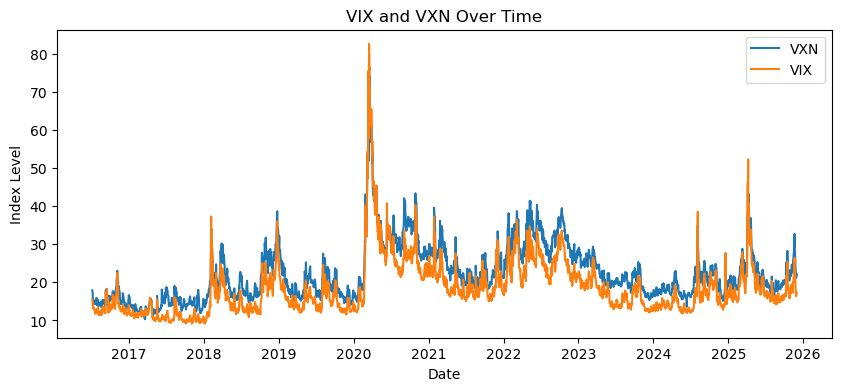

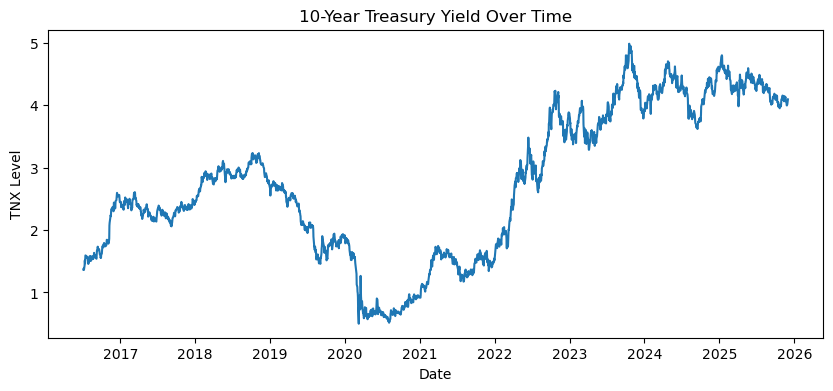

In [8]:
# Example visualization
# plt.figure(figsize=(6,4))
# df['your_column'].hist(bins=30)
# plt.title('Distribution of your_column')
# plt.show()

# =========================
# 3.2 MSFT daily return over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_return_1d'])
plt.title('MSFT Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

# =========================
# 3.3 MSFT rolling volatility
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_rolling_vol_5'], label='5-day rolling volatility')
plt.plot(model_data.index, model_data['MSFT_rolling_vol_21'], label='21-day rolling volatility')
plt.title('MSFT Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Volatility')
plt.legend()
plt.show()

# =========================
# 3.4 VIX level over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'])
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.show()

# =========================
# 3.5 Target variable summary
# =========================

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

model_data[target_cols].describe()

# =========================
# 3.6 Target volatility over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['target_volatility_1d'], label='1-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_5d'], label='5-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_21d'], label='21-day target', alpha=0.7)
plt.title('Target Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

# =========================
# 3.7 Distribution of target variables
# =========================

for col in target_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(model_data[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Volatility')
    plt.ylabel('Frequency')
    plt.show()


# =========================
# 3.8 Additional market features over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VXN_level'], label='VXN')
plt.plot(model_data.index, model_data['VIX_level'], label='VIX')
plt.title('VIX and VXN Over Time')
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['TNX_level'])
plt.title('10-Year Treasury Yield Over Time')
plt.xlabel('Date')
plt.ylabel('TNX Level')
plt.show()

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: Support Vector Regression (SVR)

**Implemented by: Jenny Fu** 

- Motivation

Support Vector Regression (SVR) is chosen because future MSFT volatility may not have a simple linear relationship with the input features. Variables such as VIX, VXN, market returns, lagged MSFT returns, and rolling volatility may affect future volatility in a nonlinear way. Compared with linear regression, SVR can use a kernel function to fit a more flexible regression relationship.

SVR is also useful because financial data are noisy. It allows small prediction errors within an epsilon margin, and only penalizes errors outside that margin. This fits our task because small volatility prediction errors are acceptable, while larger errors should be penalized.

- Model description

Support Vector Regression is the regression version of SVM. Instead of separating classes, SVR fits a function to predict a continuous target:

f(x) = w^T x + b

A key idea is the epsilon-insensitive tube. If the prediction error is within ε, there is no penalty. If the error is larger than ε, the point is outside the tube and receives a penalty.

In this project, we use SVR with an RBF kernel to capture possible nonlinear relationships between market features and future MSFT volatility. The main parameters are C, ε, and gamma. C controls the penalty strength, ε controls the tube width, and gamma controls the flexibility of the RBF kernel.

- Why this method is appropriate/Key assumptions

SVR is appropriate because stock volatility may depend on nonlinear combinations of past returns, rolling volatility, market indexes, sector ETFs, and volatility indexes. It also works reasonably well for medium-sized datasets like our 10 years of daily stock data.

The main assumption is that past and current market information contains some signal about future volatility. We also split the data chronologically to avoid using future information. Since SVR is sensitive to feature scale, we standardize the features using only the training set and apply the same scaler to the validation and test sets.

In [23]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

param_grid = [
    {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
]

In [24]:
# =========================
# SVR Model: 1-day volatility target
# =========================

y_train = y_train_1d
y_valid = y_valid_1d
y_test = y_test_1d

best_valid_rmse_1d = np.inf
best_svr_1d = None
best_params_1d = None
best_valid_pred_1d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_1d:
        best_valid_rmse_1d = valid_rmse
        best_svr_1d = svr
        best_params_1d = params
        best_valid_pred_1d = y_valid_pred

print("Best parameters for 1-day target:", best_params_1d)
print("Best validation RMSE for 1-day target:", best_valid_rmse_1d)

# Validation metrics
valid_mae_1d = mean_absolute_error(y_valid, best_valid_pred_1d)
valid_rmse_1d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_1d))
valid_r2_1d = r2_score(y_valid, best_valid_pred_1d)
valid_normalized_rmse_1d = valid_rmse_1d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_1d = best_svr_1d.predict(X_test_scaled)

# Test metrics
test_mae_1d = mean_absolute_error(y_test, y_test_pred_1d)
test_rmse_1d = np.sqrt(mean_squared_error(y_test, y_test_pred_1d))
test_r2_1d = r2_score(y_test, y_test_pred_1d)
test_normalized_rmse_1d = test_rmse_1d / np.std(y_test)

# Naive baseline on test set
baseline_pred_1d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_1d = np.sqrt(mean_squared_error(y_test, baseline_pred_1d))
improvement_1d = (baseline_rmse_1d - test_rmse_1d) / baseline_rmse_1d

print("\nSVR 1-day Validation Results")
print("Validation MAE:", valid_mae_1d)
print("Validation RMSE:", valid_rmse_1d)
print("Validation Normalized RMSE:", valid_normalized_rmse_1d)
print("Validation R2:", valid_r2_1d)

print("\nSVR 1-day Test Results")
print("Test MAE:", test_mae_1d)
print("Test RMSE:", test_rmse_1d)
print("Test Normalized RMSE:", test_normalized_rmse_1d)
print("Test R2:", test_r2_1d)
print("Baseline RMSE:", baseline_rmse_1d)
print("Improvement over baseline:", improvement_1d)

Best parameters for 1-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 1-day target: 0.011845995030077891

SVR 1-day Validation Results
Validation MAE: 0.009686623592265084
Validation RMSE: 0.011845995030077891
Validation Normalized RMSE: 1.2905120932737395
Validation R2: -0.6654214628857693

SVR 1-day Test Results
Test MAE: 0.011523057804545959
Test RMSE: 0.014276749472611271
Test Normalized RMSE: 1.3239844014684388
Test R2: -0.7529346953317386
Baseline RMSE: 0.010976990895077013
Improvement over baseline: -0.3006068429021055


In [25]:
# =========================
# SVR Model: 5-day volatility target
# =========================

y_train = y_train_5d
y_valid = y_valid_5d
y_test = y_test_5d

best_valid_rmse_5d = np.inf
best_svr_5d = None
best_params_5d = None
best_valid_pred_5d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_5d:
        best_valid_rmse_5d = valid_rmse
        best_svr_5d = svr
        best_params_5d = params
        best_valid_pred_5d = y_valid_pred

print("Best parameters for 5-day target:", best_params_5d)
print("Best validation RMSE for 5-day target:", best_valid_rmse_5d)

# Validation metrics
valid_mae_5d = mean_absolute_error(y_valid, best_valid_pred_5d)
valid_rmse_5d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_5d))
valid_r2_5d = r2_score(y_valid, best_valid_pred_5d)
valid_normalized_rmse_5d = valid_rmse_5d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_5d = best_svr_5d.predict(X_test_scaled)

# Test metrics
test_mae_5d = mean_absolute_error(y_test, y_test_pred_5d)
test_rmse_5d = np.sqrt(mean_squared_error(y_test, y_test_pred_5d))
test_r2_5d = r2_score(y_test, y_test_pred_5d)
test_normalized_rmse_5d = test_rmse_5d / np.std(y_test)

# Naive baseline on test set
baseline_pred_5d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_5d = np.sqrt(mean_squared_error(y_test, baseline_pred_5d))
improvement_5d = (baseline_rmse_5d - test_rmse_5d) / baseline_rmse_5d

print("\nSVR 5-day Validation Results")
print("Validation MAE:", valid_mae_5d)
print("Validation RMSE:", valid_rmse_5d)
print("Validation Normalized RMSE:", valid_normalized_rmse_5d)
print("Validation R2:", valid_r2_5d)

print("\nSVR 5-day Test Results")
print("Test MAE:", test_mae_5d)
print("Test RMSE:", test_rmse_5d)
print("Test Normalized RMSE:", test_normalized_rmse_5d)
print("Test R2:", test_r2_5d)
print("Baseline RMSE:", baseline_rmse_5d)
print("Improvement over baseline:", improvement_5d)

Best parameters for 5-day target: {'C': 1, 'epsilon': 0.005, 'gamma': 'scale'}
Best validation RMSE for 5-day target: 0.008564303826853931

SVR 5-day Validation Results
Validation MAE: 0.006708181940214439
Validation RMSE: 0.008564303826853931
Validation Normalized RMSE: 1.4748938119233628
Validation R2: -1.1753117564498292

SVR 5-day Test Results
Test MAE: 0.01196889954186395
Test RMSE: 0.014391547025863654
Test Normalized RMSE: 1.8443129441252186
Test R2: -2.4014902358678336
Baseline RMSE: 0.008122148296954654
Improvement over baseline: -0.7718892218773781


In [26]:
# =========================
# SVR Model: 21-day volatility target
# =========================

y_train = y_train_21d
y_valid = y_valid_21d
y_test = y_test_21d

best_valid_rmse_21d = np.inf
best_svr_21d = None
best_params_21d = None
best_valid_pred_21d = None

for params in param_grid:
    svr = SVR(
        kernel='rbf',
        C=params['C'],
        epsilon=params['epsilon'],
        gamma=params['gamma']
    )
    
    # Train on training set
    svr.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_valid_pred = svr.predict(X_valid_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    
    # Select best hyperparameters using validation RMSE
    if valid_rmse < best_valid_rmse_21d:
        best_valid_rmse_21d = valid_rmse
        best_svr_21d = svr
        best_params_21d = params
        best_valid_pred_21d = y_valid_pred

print("Best parameters for 21-day target:", best_params_21d)
print("Best validation RMSE for 21-day target:", best_valid_rmse_21d)

# Validation metrics
valid_mae_21d = mean_absolute_error(y_valid, best_valid_pred_21d)
valid_rmse_21d = np.sqrt(mean_squared_error(y_valid, best_valid_pred_21d))
valid_r2_21d = r2_score(y_valid, best_valid_pred_21d)
valid_normalized_rmse_21d = valid_rmse_21d / np.std(y_valid)

# Test prediction using the selected best model
y_test_pred_21d = best_svr_21d.predict(X_test_scaled)

# Test metrics
test_mae_21d = mean_absolute_error(y_test, y_test_pred_21d)
test_rmse_21d = np.sqrt(mean_squared_error(y_test, y_test_pred_21d))
test_r2_21d = r2_score(y_test, y_test_pred_21d)
test_normalized_rmse_21d = test_rmse_21d / np.std(y_test)

# Naive baseline on test set
baseline_pred_21d = np.repeat(y_train.mean(), len(y_test))
baseline_rmse_21d = np.sqrt(mean_squared_error(y_test, baseline_pred_21d))
improvement_21d = (baseline_rmse_21d - test_rmse_21d) / baseline_rmse_21d

print("\nSVR 21-day Validation Results")
print("Validation MAE:", valid_mae_21d)
print("Validation RMSE:", valid_rmse_21d)
print("Validation Normalized RMSE:", valid_normalized_rmse_21d)
print("Validation R2:", valid_r2_21d)

print("\nSVR 21-day Test Results")
print("Test MAE:", test_mae_21d)
print("Test RMSE:", test_rmse_21d)
print("Test Normalized RMSE:", test_normalized_rmse_21d)
print("Test R2:", test_r2_21d)
print("Baseline RMSE:", baseline_rmse_21d)
print("Improvement over baseline:", improvement_21d)

Best parameters for 21-day target: {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
Best validation RMSE for 21-day target: 0.00973220316876469

SVR 21-day Validation Results
Validation MAE: 0.008321940254686222
Validation RMSE: 0.00973220316876469
Validation Normalized RMSE: 3.259010761582602
Validation R2: -9.62115114411121

SVR 21-day Test Results
Test MAE: 0.0112868789624687
Test RMSE: 0.012423933540694076
Test Normalized RMSE: 2.307710702403313
Test R2: -4.325528685986792
Baseline RMSE: 0.005766145566363717
Improvement over baseline: -1.1546340441295755


In [27]:
# =========================
# SVR Summary Table
# =========================

svr_summary = pd.DataFrame({
    "Target": [
        "1-day volatility",
        "5-day volatility",
        "21-day volatility"
    ],
    
    "Best Parameters": [
        best_params_1d,
        best_params_5d,
        best_params_21d
    ],
    
    "Validation RMSE": [
        valid_rmse_1d,
        valid_rmse_5d,
        valid_rmse_21d
    ],
    
    "Validation Normalized RMSE": [
        valid_normalized_rmse_1d,
        valid_normalized_rmse_5d,
        valid_normalized_rmse_21d
    ],
    
    "Test MAE": [
        test_mae_1d,
        test_mae_5d,
        test_mae_21d
    ],
    
    "Test RMSE": [
        test_rmse_1d,
        test_rmse_5d,
        test_rmse_21d
    ],
    
    "Test Normalized RMSE": [
        test_normalized_rmse_1d,
        test_normalized_rmse_5d,
        test_normalized_rmse_21d
    ],
    
    "Test R2": [
        test_r2_1d,
        test_r2_5d,
        test_r2_21d
    ],
    
    "Baseline RMSE": [
        baseline_rmse_1d,
        baseline_rmse_5d,
        baseline_rmse_21d
    ],
    
    "Improvement over Baseline": [
        improvement_1d,
        improvement_5d,
        improvement_21d
    ]
})

svr_summary_rounded = svr_summary.copy()

numeric_cols = [
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Test MAE",
    "Test RMSE",
    "Test Normalized RMSE",
    "Test R2",
    "Baseline RMSE",
    "Improvement over Baseline"
]

svr_summary_rounded[numeric_cols] = svr_summary_rounded[numeric_cols].round(4)

svr_summary_rounded

,Target,Best Parameters,Validation RMSE,Validation Normalized RMSE,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0118,1.2905,0.0115,0.0143,1.3240,-0.7529,0.0110,-0.3006
1,5-day volatility,"{'C': 1, 'epsilon': 0.005, 'gamma': 'scale'}",0.0086,1.4749,0.0120,0.0144,1.8443,-2.4015,0.0081,-0.7719
2,21-day volatility,"{'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}",0.0097,3.2590,0.0113,0.0124,2.3077,-4.3255,0.0058,-1.1546


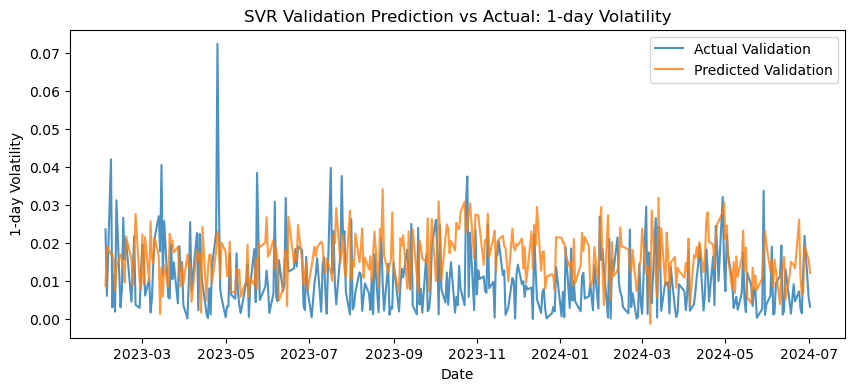

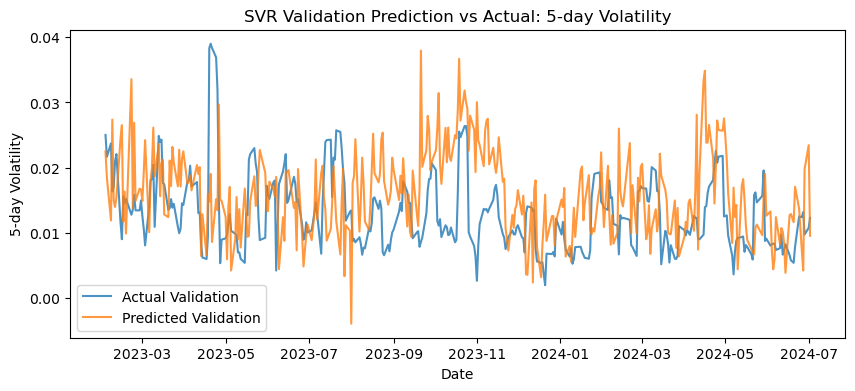

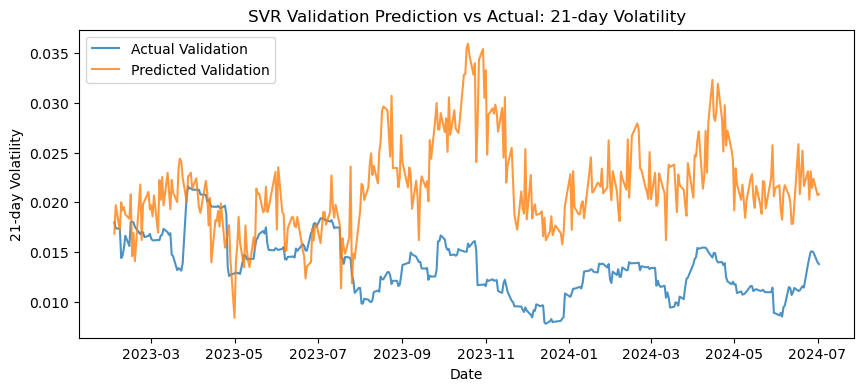

In [28]:
# =========================
# SVR Validation Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_1d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_1d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_5d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_5d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(valid_data.index, y_valid_21d, label='Actual Validation', alpha=0.8)
plt.plot(valid_data.index, best_valid_pred_21d, label='Predicted Validation', alpha=0.8)
plt.title('SVR Validation Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

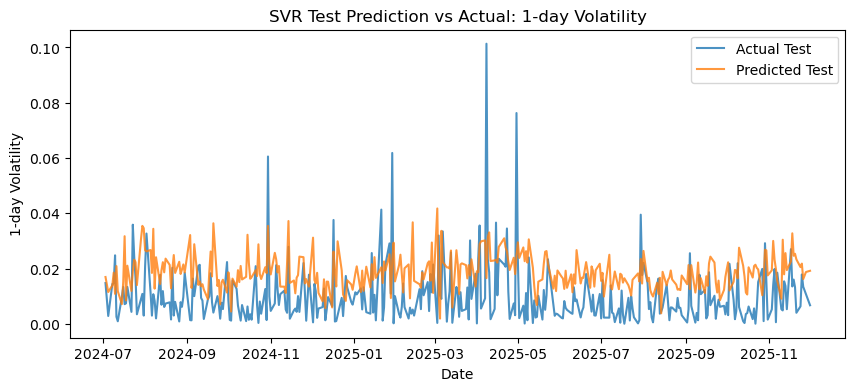

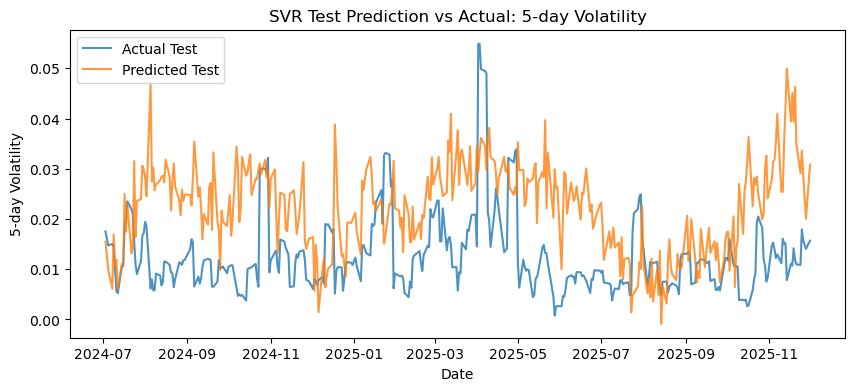

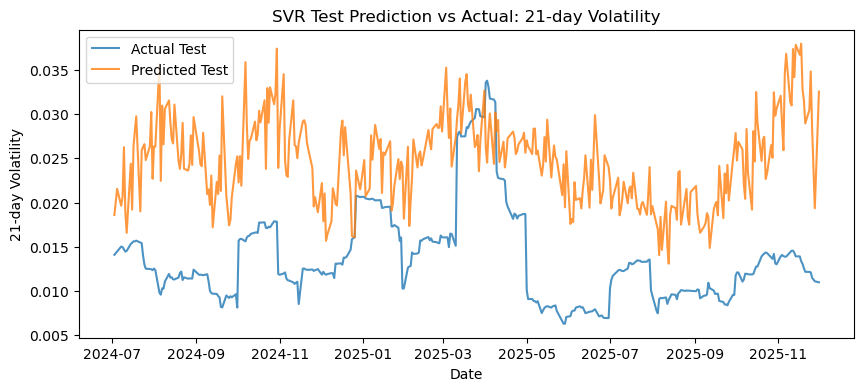

In [29]:
# =========================
# SVR Test Prediction vs Actual Plots
# =========================

plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_1d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_1d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 1-day Volatility')
plt.xlabel('Date')
plt.ylabel('1-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_5d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_5d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 5-day Volatility')
plt.xlabel('Date')
plt.ylabel('5-day Volatility')
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(test_data.index, y_test_21d, label='Actual Test', alpha=0.8)
plt.plot(test_data.index, y_test_pred_21d, label='Predicted Test', alpha=0.8)
plt.title('SVR Test Prediction vs Actual: 21-day Volatility')
plt.xlabel('Date')
plt.ylabel('21-day Volatility')
plt.legend()
plt.show()

## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu** 

- Motivation

    Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

    Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

    This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


Repeat until Model N (N=your group size)

Best Gradient Boosting validation performance:


,Horizon,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized MAE,Validation R2
0,Daily 1D,100,0.01,2,0.006936,0.008972,0.645822,0.044613
1,Weekly 5D,50,0.01,2,0.004455,0.005677,0.341303,0.044046
2,Monthly 21D,50,0.01,2,0.002881,0.003478,0.211486,-0.356148


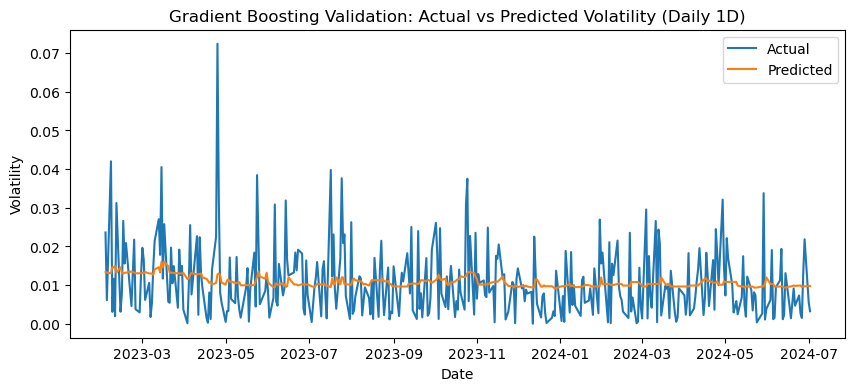

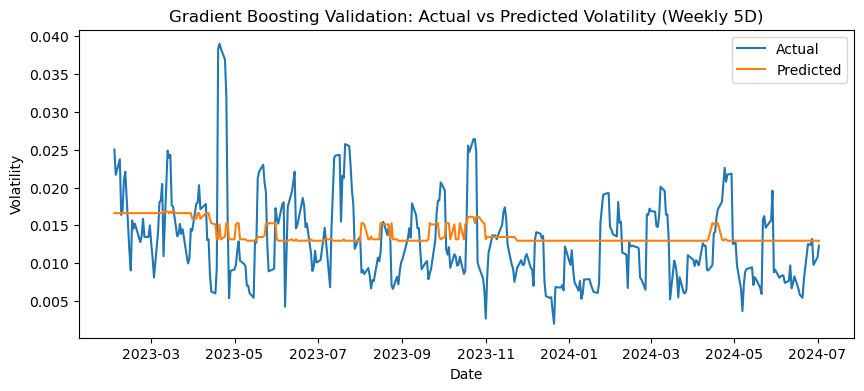

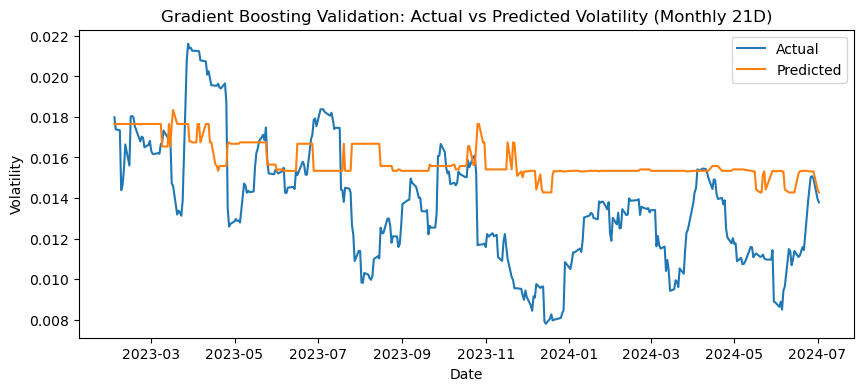

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

# Targets for validation tuning
targets = {
    'Daily 1D': (y_train_1d, y_valid_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d)
}

# Candidate hyperparameters
param_grid = [
    {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]

tuning_results = []

for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    
    for params in param_grid:
        
        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            random_state=42
        )
        
        # Train on training set only
        model.fit(X_train_scaled, y_train)
        
        # Predict on validation set only
        y_valid_pred = model.predict(X_valid_scaled)
        
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_mae = valid_mae / y_valid.mean()
        
        tuning_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation Normalized MAE': valid_normalized_mae,
            'Validation R2': valid_r2
        })

tuning_results_df = pd.DataFrame(tuning_results)

# Sort full tuning table by horizon and normalized MAE
tuning_results_df['Horizon'] = pd.Categorical(
    tuning_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

tuning_results_df = (
    tuning_results_df
    .sort_values(['Horizon', 'Validation Normalized MAE'])
    .reset_index(drop=True)
)

tuning_results_df

# Select best parameters for each horizon
best_params_by_horizon = (
    tuning_results_df
    .sort_values('Validation Normalized MAE')
    .groupby('Horizon', observed=True)
    .first()
    .reset_index()
)

best_params_by_horizon['Horizon'] = pd.Categorical(
    best_params_by_horizon['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_params_by_horizon = (
    best_params_by_horizon
    .sort_values('Horizon')
    .reset_index(drop=True)
)


# Refit best Gradient Boosting models and plot validation predictions
best_gb_models = {}
best_gb_valid_predictions = {}
best_gb_valid_results = []

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    y_train, y_valid = targets[horizon]
    
    model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    # Train on training set only
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_valid_pred = model.predict(X_valid_scaled)
    
    # Validation metrics
    valid_mae = mean_absolute_error(y_valid, y_valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    valid_r2 = r2_score(y_valid, y_valid_pred)
    valid_normalized_mae = valid_mae / y_valid.mean()
    
    best_gb_valid_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Validation MAE': valid_mae,
        'Validation RMSE': valid_rmse,
        'Validation Normalized MAE': valid_normalized_mae,
        'Validation R2': valid_r2
    })
    
    best_gb_models[horizon] = model
    best_gb_valid_predictions[horizon] = y_valid_pred

best_gb_valid_results_df = pd.DataFrame(best_gb_valid_results)

best_gb_valid_results_df['Horizon'] = pd.Categorical(
    best_gb_valid_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_gb_valid_results_df = (
    best_gb_valid_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Best Gradient Boosting validation performance:")
display(best_gb_valid_results_df)

# Validation actual vs predicted plots using best models
for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    y_valid_pred = best_gb_valid_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_valid.index, y_valid, label='Actual')
    plt.plot(y_valid.index, y_valid_pred, label='Predicted')
    plt.title(f'Gradient Boosting Validation: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

Top 10 Feature Importances for Daily 1D:


,Feature,Importance
28,VXN_level,0.443849
9,MSFT_log_volume,0.211935
30,VXN_lag1,0.088562
27,VIX_rolling_mean_63,0.073998
7,MSFT_rolling_vol_5,0.063170
16,VIX_level,0.059471
13,SPY_rolling_vol_21,0.021984
4,MSFT_return_lag10,0.016582
20,XLK_rolling_vol_5,0.010010
3,MSFT_return_lag5,0.006523


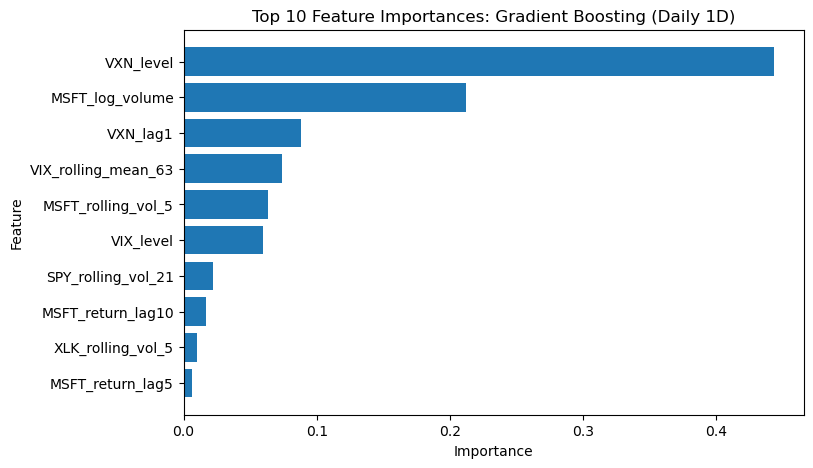

Top 10 Feature Importances for Weekly 5D:


,Feature,Importance
28,VXN_level,0.363100
20,XLK_rolling_vol_5,0.337997
12,SPY_rolling_vol_5,0.106002
16,VIX_level,0.041459
13,SPY_rolling_vol_21,0.040700
27,VIX_rolling_mean_63,0.032246
35,SOXX_rolling_vol_21,0.018341
8,MSFT_rolling_vol_21,0.014573
37,TLT_rolling_vol_21,0.013955
21,XLK_rolling_vol_21,0.009062


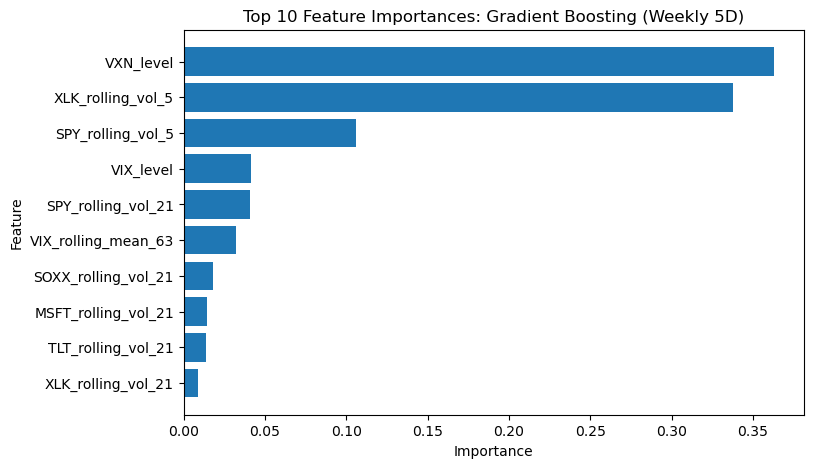

Top 10 Feature Importances for Monthly 21D:


,Feature,Importance
8,MSFT_rolling_vol_21,0.393555
28,VXN_level,0.264686
20,XLK_rolling_vol_5,0.209266
25,MSFT_rolling_vol_126,0.093870
9,MSFT_log_volume,0.019053
31,TNX_level,0.008105
30,VXN_lag1,0.005269
33,TNX_lag1,0.004060
13,SPY_rolling_vol_21,0.002136
4,MSFT_return_lag10,0.000000


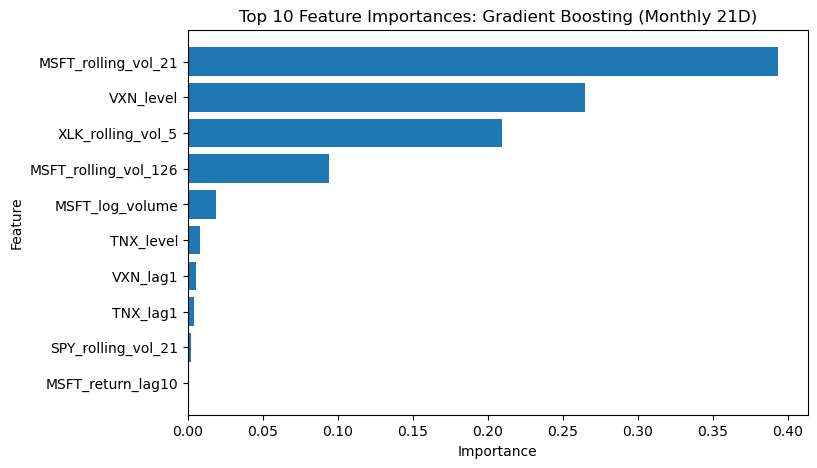

In [10]:
# Feature Importance for Best Gradient Boosting Models
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_dfs = {}

for horizon in horizon_order:
    
    model = best_gb_models[horizon]
    
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    feature_importance_dfs[horizon] = importance_df
    
    print(f"Top 10 Feature Importances for {horizon}:")
    display(importance_df.head(10))
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df.head(10)['Feature'][::-1],
        importance_df.head(10)['Importance'][::-1]
    )
    plt.title(f'Top 10 Feature Importances: Gradient Boosting ({horizon})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

Final Gradient Boosting Test Performance:


,Horizon,n_estimators,learning_rate,max_depth,Test MAE,Test RMSE,Test Normalized MAE,Test R2
0,Daily 1D,100,0.01,2,0.007432,0.010603,0.738618,0.033094
1,Weekly 5D,50,0.01,2,0.005854,0.007888,0.463191,-0.021850
2,Monthly 21D,50,0.01,2,0.004159,0.005339,0.303026,0.016440


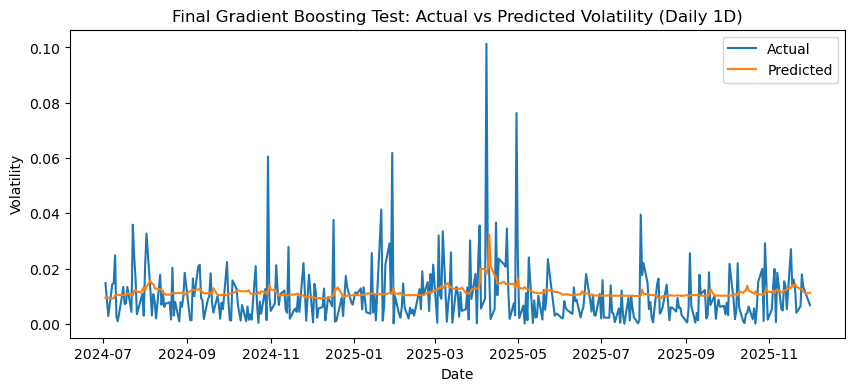

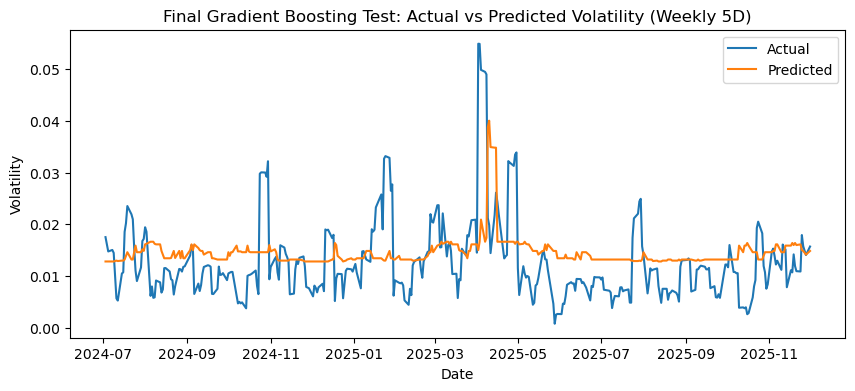

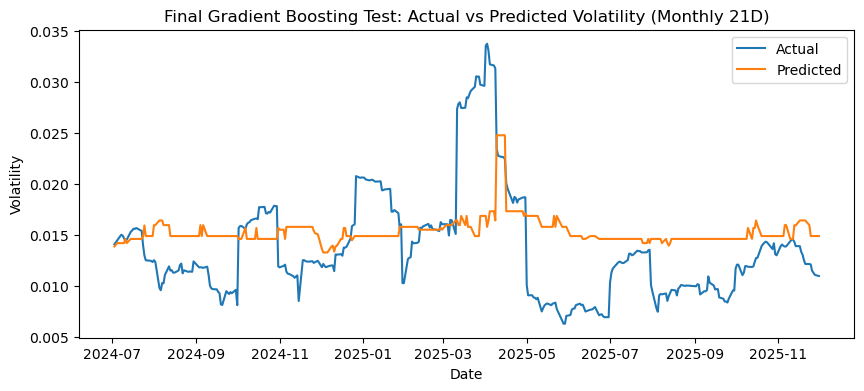

In [14]:

# Final Test Evaluation using Best Validation Parameters
from IPython.display import display

# Horizon order
horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets_full = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

# Combine train + validation features
X_train_valid = pd.concat([X_train, X_valid])

final_scaler = StandardScaler()

X_train_valid_scaled = final_scaler.fit_transform(X_train_valid)
X_test_scaled_final = final_scaler.transform(X_test)

X_train_valid_scaled = pd.DataFrame(
    X_train_valid_scaled,
    index=X_train_valid.index,
    columns=feature_cols
)

X_test_scaled_final = pd.DataFrame(
    X_test_scaled_final,
    index=X_test.index,
    columns=feature_cols
)


# Final model training and test evaluation
final_test_results = []
final_gb_models = {}
final_gb_test_predictions = {}

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    
    y_train, y_valid, y_test = targets_full[horizon]
    
    y_train_valid = pd.concat([y_train, y_valid])
    
    final_model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    final_model.fit(X_train_valid_scaled, y_train_valid)
    
    # Predict on test set only
    y_test_pred = final_model.predict(X_test_scaled_final)
    
    # Test metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_normalized_mae = test_mae / y_test.mean()
    
    final_test_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test Normalized MAE': test_normalized_mae,
        'Test R2': test_r2
    })
    
    final_gb_models[horizon] = final_model
    final_gb_test_predictions[horizon] = y_test_pred


# Create final test results DataFrame
final_test_results_df = pd.DataFrame(final_test_results)

final_test_results_df['Horizon'] = pd.Categorical(
    final_test_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

final_test_results_df = (
    final_test_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Final Gradient Boosting Test Performance:")
display(final_test_results_df)


# Test Actual vs Predicted Plots
for horizon in horizon_order:
    
    _, _, y_test = targets_full[horizon]
    y_test_pred = final_gb_test_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_test_pred, label='Predicted')
    plt.title(f'Final Gradient Boosting Test: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

## 4.4 Model 3: ___

**Implemented by: Shawn Wen** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


## 4.5 Model 4: ___

**Implemented by: Summer Zhu** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [10]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
